#### The code below is a function that compares two Random Forest models with different feature sets against three baselines.
Run it first before doing the other things

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

def compare_feature_sets(df, features_1, features_2, name_1="Model 1", name_2="Model 2"):
    """
    Compares two Random Forest models with different feature sets against three baselines.
    
    Parameters:
    - df: Pre-processed DataFrame (must include 'tickets_scanned', 'season', 'opponent_avg', 'same_fixture_baseline')
    - features_1: List of column names for the first model
    - features_2: List of column names for the second model
    - name_1: Label for the first model in the plot/logs
    - name_2: Label for the second model in the plot/logs
    """
    
    seasons = sorted(df["season"].unique())
    season_results = []
    
    # Identify the union of all necessary columns so we drop NaNs fairly (apples-to-apples comparison)
    required_cols = list(set(features_1 + features_2 + ["tickets_scanned", "season", "opponent_avg", "same_fixture_baseline"]))
    df_clean = df.dropna(subset=required_cols).copy()

    print(f"{'='*80}")
    print(f"FEATURE SET COMPARISON: {name_1} vs {name_2}")
    print(f"{'='*80}")

    for test_season in seasons:
        train = df_clean[df_clean["season"] != test_season].copy()
        test  = df_clean[df_clean["season"] == test_season].copy()

        if len(train) < 10 or len(test) < 5:
            continue

        y_train = train["tickets_scanned"]
        y_test  = test["tickets_scanned"]

        # --- AUTOMATIC CATEGORICAL ENCODING ---
        # Feature Set 1
        cat_cols_1 = train[features_1].select_dtypes(exclude=[np.number]).columns.tolist()
        X_train_1 = pd.get_dummies(train[features_1], columns=cat_cols_1, drop_first=True)
        X_test_1  = pd.get_dummies(test[features_1], columns=cat_cols_1, drop_first=True)
        X_test_1  = X_test_1.reindex(columns=X_train_1.columns, fill_value=0)

        # Feature Set 2
        cat_cols_2 = train[features_2].select_dtypes(exclude=[np.number]).columns.tolist()
        X_train_2 = pd.get_dummies(train[features_2], columns=cat_cols_2, drop_first=True)
        X_test_2  = pd.get_dummies(test[features_2], columns=cat_cols_2, drop_first=True)
        X_test_2  = X_test_2.reindex(columns=X_train_2.columns, fill_value=0)

        # --- BASELINES ---
        season_avg_val = train["tickets_scanned"].mean()
        pred_season   = np.full(shape=len(y_test), fill_value=season_avg_val)
        pred_opponent = test["opponent_avg"]
        pred_fixture  = test["same_fixture_baseline"]

        # --- MODEL TRAINING ---
        rf = RandomForestRegressor(n_estimators=200, max_depth=5, min_samples_split=5, min_samples_leaf=2, random_state=42)
        
        rf.fit(X_train_1, y_train)
        pred_m1 = rf.predict(X_test_1)
        
        rf.fit(X_train_2, y_train)
        pred_m2 = rf.predict(X_test_2)

        # --- METRICS CALCULATION (MAE & Largest Error) ---
        def get_metrics(y_true, y_pred):
            mae = mean_absolute_error(y_true, y_pred)
            max_err = np.max(np.abs(y_true - y_pred))
            return mae, max_err

        mae_seas, err_seas = get_metrics(y_test, pred_season)
        mae_opp,  err_opp  = get_metrics(y_test, pred_opponent)
        mae_fix,  err_fix  = get_metrics(y_test, pred_fixture)
        mae_m1,   err_m1   = get_metrics(y_test, pred_m1)
        mae_m2,   err_m2   = get_metrics(y_test, pred_m2)

        # Save for plotting
        season_results.append({
            "season": test_season,
            "Baseline: Season Avg": mae_seas,
            "Baseline: Opponent Avg": mae_opp,
            "Baseline: Same Fixture": mae_fix,
            name_1: mae_m1,
            name_2: mae_m2
        })

        # Print detailed logs for this season
        print(f"\n--- SEASON: {test_season} (n={len(y_test)} matches) ---")
        print(f"{'Model / Baseline':<25} | {'MAE':<8} | {'Largest Error':<13}")
        print("-" * 52)
        print(f"{'Baseline: Season Avg':<25} | {mae_seas:<8.0f} | {err_seas:<13.0f}")
        print(f"{'Baseline: Opponent Avg':<25} | {mae_opp:<8.0f} | {err_opp:<13.0f}")
        print(f"{'Baseline: Same Fixture':<25} | {mae_fix:<8.0f} | {err_fix:<13.0f}")
        print(f"{name_1:<25} | {mae_m1:<8.0f} | {err_m1:<13.0f}")
        print(f"{name_2:<25} | {mae_m2:<8.0f} | {err_m2:<13.0f}")

    # --- VISUALIZATION ---
    results_df = pd.DataFrame(season_results).set_index("season")
    cols = ["Baseline: Season Avg", "Baseline: Opponent Avg", "Baseline: Same Fixture", name_1, name_2]
    
    # Colors: Greys for baselines, Dark Green for Model 1, Navy Blue for Model 2
    colors = ["#d9d9d9", "#bdbdbd", "#969696", "#2ca02c", "#1f77b4"]

    x = np.arange(len(results_df))
    width = 0.15 # Thinner bars to fit 5 per group

    fig, ax = plt.subplots(figsize=(12, 6))

    # Plot each bar with an offset so they group side-by-side
    offsets = [-2*width, -width, 0, width, 2*width]
    for i, (col, color) in enumerate(zip(cols, colors)):
        ax.bar(x + offsets[i], results_df[col], width=width, label=col, color=color)

    ax.set_xticks(x)
    ax.set_xticklabels(results_df.index, rotation=0)
    ax.set_ylabel("Mean Absolute Error (MAE)")
    ax.set_title(f"Model Comparison: {name_1} vs {name_2} (MAE per Season)")
    ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

    

Seasons available: ['2022/2023', '2023/2024', '2024/2025', '2025/2026']
2022/2023 — RF: 1606 | Opponent Avg: 2068 | Season Avg: 1828 | Same Fixture: 2068 | n=13
2023/2024 — RF: 1702 | Opponent Avg: 2761 | Season Avg: 2321 | Same Fixture: 2911 | n=19
2024/2025 — RF: 1560 | Opponent Avg: 1532 | Season Avg: 1601 | Same Fixture: 1909 | n=20
2025/2026 — RF: 806 | Opponent Avg: 1387 | Season Avg: 1416 | Same Fixture: 1410 | n=13


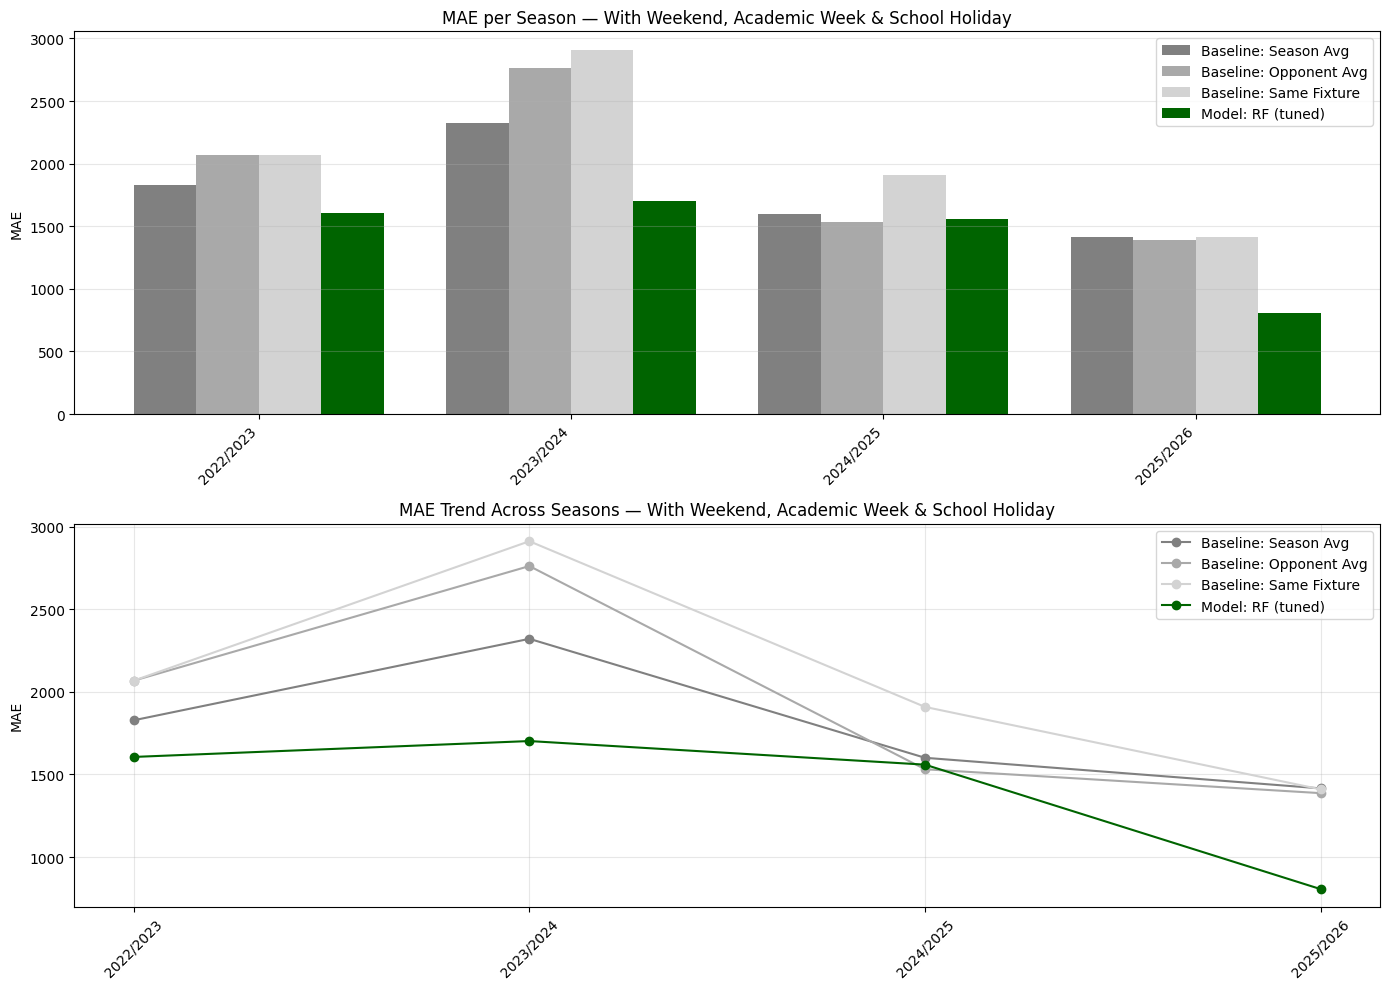

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# 1. Load Data
match   = pd.read_csv("../data/gold_match_with_league_standings.csv")
tickets = pd.read_csv("../data/gold_match_tickets.csv")
context = pd.read_csv("../data/gold_match_context.csv")

# 2. Filter and Merge
match = match[match["is_home_match"] == True]

df = match.merge(tickets, on="match_id", how="left")
df = df.merge(context, on="match_id", how="left")

# Handle potential suffix issues from merges
if "match_date_x" in df.columns:
    df = df.rename(columns={"match_date_x": "match_date"})
elif "match_date_y" in df.columns:
    df = df.rename(columns={"match_date_y": "match_date"})

# Clean up baseline data
df = df[df["away_team"] != "OH Leuven"]
df = df.dropna(subset=["tickets_scanned", "last_result_vs_opponent"])

# 3. Parse target/results
def parse_result(value):
    if pd.isna(value): return None
    if value.startswith("W"): return 3
    elif value.startswith("D"): return 1
    elif value.startswith("L"): return 0
    return None

df["last_result_numeric"] = df["last_result_vs_opponent"].apply(parse_result)
df = df.dropna(subset=["last_result_numeric"])

# -------------------------------------------------------------------
# CRITICAL FIX 1: SORT CHRONOLOGICALLY AND RESET INDEX
# All time-series features must be calculated chronologically to prevent data leakage.
# -------------------------------------------------------------------
df["match_date"] = pd.to_datetime(df["match_date"])
df = df.sort_values("match_date").reset_index(drop=True)

# -------------------------------------------------------------------
# CRITICAL FIX 2: GLOBAL TIME-SERIES FEATURES
# Calculate lags globally before splitting to avoid constant values in test sets.
# -------------------------------------------------------------------
df["last_home_attendance"] = df["tickets_scanned"].shift(1)
df["rolling_avg_3"]        = df["tickets_scanned"].shift(1).rolling(3).mean()

# Calculate expanding opponent average (average attendance for this opponent strictly UP TO this date)
df["opponent_avg"] = df.groupby("away_team")["tickets_scanned"].transform(lambda x: x.shift().expanding().mean())
df["season_expanding_avg"] = df["tickets_scanned"].shift().expanding().mean()
df["opponent_avg"] = df["opponent_avg"].fillna(df["season_expanding_avg"]) # Fallback for first-time opponents

# Calculate Same Fixture Last Time (strictly UP TO this date)
def get_last_fixture(row, dataframe):
    past = dataframe[(dataframe["away_team"] == row["away_team"]) & (dataframe["match_date"] < row["match_date"])]
    if not past.empty:
        return past.iloc[-1]["tickets_scanned"]
    return np.nan

df["same_fixture_baseline"] = df.apply(lambda r: get_last_fixture(r, df), axis=1)
df["same_fixture_baseline"] = df["same_fixture_baseline"].fillna(df["season_expanding_avg"])

# Fix recent form logic to compare actual Dates, not original CSV row indices
records = []
for idx, row in df.iterrows():
    past = df[(df["away_team"] == row["away_team"]) & (df["match_date"] < row["match_date"])]
    results = past["last_result_numeric"].tail(3).tolist()

    records.append({
        "match_id":       row["match_id"],
        "result_minus_1": results[-1] if len(results) >= 1 else None,
        "result_minus_2": results[-2] if len(results) >= 2 else None,
        "result_minus_3": results[-3] if len(results) >= 3 else None,
    })

df_lag = pd.DataFrame(records)
df = df.merge(df_lag, on="match_id", how="left")
df["points_last_3"] = df["result_minus_1"].fillna(0) + df["result_minus_2"].fillna(0) + df["result_minus_3"].fillna(0)

df["school_holiday_name"] = df["school_holiday_name"].fillna("None")

df["kickoff_time_local"] = pd.to_datetime(df["kickoff_time_local"], format='%H:%M:%S')
df["kickoff_time_local"] = pd.to_datetime(df["kickoff_time_local"], format='%H:%M:%S').dt.hour
df["is_18_hours"] = df["kickoff_time_local"] == 18

# Drop the rows at the very beginning of the dataset that don't have enough history for lags
df = df.dropna(subset=["last_home_attendance", "rolling_avg_3"])

# -------------------------------------------------------------------
# MODELING PREPARATION
# -------------------------------------------------------------------
seasons = sorted(df["season"].unique())
print(f"Seasons available: {seasons}")

categorical_features = ["stage", "school_holiday_name"]
numerical_features   = ["opponent_avg", "last_home_attendance", "rolling_avg_3", "matchday", "is_weekend", "academic_week", "is_18_hours"]
features = numerical_features + categorical_features

season_results = []

# Leave-One-Season-Out Cross Validation
for test_season in seasons:
    train = df[df["season"] != test_season].copy()
    test  = df[df["season"] == test_season].copy()

    # Need minimum data to train/test
    if len(train) < 10 or len(test) < 5:
        continue

    # Drop any remaining NAs strictly within the selected features
    train = train.dropna(subset=features)
    test  = test.dropna(subset=features)

    if len(test) == 0:
        continue

    # One-Hot Encoding
    X_train = pd.get_dummies(train[features], columns=categorical_features, drop_first=True)
    X_test  = pd.get_dummies(test[features],  columns=categorical_features, drop_first=True)

    # Align columns to ensure train and test have the exact same dummy variables
    X_test  = X_test.reindex(columns=X_train.columns, fill_value=0)

    y_train = train["tickets_scanned"]
    y_test  = test["tickets_scanned"]

    # Baselines (Using our safely engineered features)
    # Season Avg: We only take the mean of the training set to prevent leakage
    season_avg_val = train["tickets_scanned"].mean()

    mae_season   = mean_absolute_error(y_test, [season_avg_val] * len(y_test))
    mae_opponent = mean_absolute_error(y_test, test["opponent_avg"])
    mae_fixture  = mean_absolute_error(y_test, test["same_fixture_baseline"])

    # Train Model
    rf = RandomForestRegressor(n_estimators=200, max_depth=5, min_samples_split=5, min_samples_leaf=2, random_state=42)
    rf.fit(X_train, y_train)
    mae_rf = mean_absolute_error(y_test, rf.predict(X_test))

    season_results.append({
        "season":                 test_season,
        "n_matches":              len(y_test),
        "Baseline: Season Avg":   mae_season,
        "Baseline: Opponent Avg": mae_opponent,
        "Baseline: Same Fixture": mae_fixture,
        "Model: RF (tuned)":      mae_rf,
    })
    print(f"{test_season} — RF: {mae_rf:.0f} | Opponent Avg: {mae_opponent:.0f} | Season Avg: {mae_season:.0f} | Same Fixture: {mae_fixture:.0f} | n={len(y_test)}")

# -------------------------------------------------------------------
# VISUALIZATION
# -------------------------------------------------------------------
results_df = pd.DataFrame(season_results).set_index("season")

cols   = ["Baseline: Season Avg", "Baseline: Opponent Avg", "Baseline: Same Fixture", "Model: RF (tuned)"]
colors = ["grey", "darkgrey", "lightgrey", "darkgreen"]

x     = range(len(results_df))
width = 0.2

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Top Plot: Bar Chart
for i, (col, color) in enumerate(zip(cols, colors)):
    axes[0].bar([xi + i * width for xi in x], results_df[col], width=width, label=col, color=color)

axes[0].set_xticks([xi + width * 1.5 for xi in x])
axes[0].set_xticklabels(results_df.index, rotation=45, ha="right")
axes[0].set_ylabel("MAE")
axes[0].set_title("MAE per Season — With Weekend, Academic Week & School Holiday")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# Bottom Plot: Line Chart
for col, color in zip(cols, colors):
    axes[1].plot(results_df.index, results_df[col], marker="o", label=col, color=color)

axes[1].set_ylabel("MAE")
axes[1].set_title("MAE Trend Across Seasons — With Weekend, Academic Week & School Holiday")
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

#### 1. THE SANDBOX: FEATURE ENGINEERING

In [34]:

df = df.sort_values("match_date").reset_index(drop=True)

df["last_home_attendance"] = df["tickets_scanned"].shift(1)

df["rolling_avg_3"] = df["tickets_scanned"].shift(1).rolling(window=3).mean()

df["rolling_avg_2"] = df["tickets_scanned"].shift(1).rolling(window=2).mean()


df["opponent_avg"] = df.groupby("away_team")["tickets_scanned"].transform(lambda x: x.shift().expanding().mean())
df["season_expanding_avg"] = df["tickets_scanned"].shift().expanding().mean()
df["opponent_avg"] = df["opponent_avg"].fillna(df["season_expanding_avg"])

df["school_holiday_name"] = df["school_holiday_name"].fillna("None")

#added
df["promo_tickets_total"] = df["promo_tickets_total"].fillna("0")
df["has_promotion"] = df["has_promotion"].fillna("True")



df = df.dropna(subset=["last_home_attendance", "rolling_avg_3"])



#### 2. THE MENU: DEFINE YOUR FEATURE LISTS

In [35]:
features_basic = [
     "opponent_avg",
    "last_home_attendance",
    "rolling_avg_3",
    "matchday",
    "is_weekend",
    "academic_week",
    "stage",
    "school_holiday_name"
]
# add here
features_custom = [
    "opponent_avg",
    "last_home_attendance",
    "rolling_avg_2",
    "matchday",
    "is_weekend",
    "academic_week",
    "stage",
    "school_holiday_name",
    "has_promotion"
]

#### 3. THE TEST: RUN THE COMPARISON

FEATURE SET COMPARISON: Base Model vs New Attempt

--- SEASON: 2022/2023 (n=10 matches) ---
Model / Baseline          | MAE      | Largest Error
----------------------------------------------------
Baseline: Season Avg      | 2262     | 3854         
Baseline: Opponent Avg    | 2392     | 4675         
Baseline: Same Fixture    | 2334     | 4830         
Base Model                | 1697     | 3864         
New Attempt               | 1550     | 3885         

--- SEASON: 2023/2024 (n=19 matches) ---
Model / Baseline          | MAE      | Largest Error
----------------------------------------------------
Baseline: Season Avg      | 2338     | 4624         
Baseline: Opponent Avg    | 2560     | 5378         
Baseline: Same Fixture    | 2911     | 5378         
Base Model                | 1612     | 3515         
New Attempt               | 1543     | 3411         

--- SEASON: 2024/2025 (n=20 matches) ---
Model / Baseline          | MAE      | Largest Error
-----------------------------

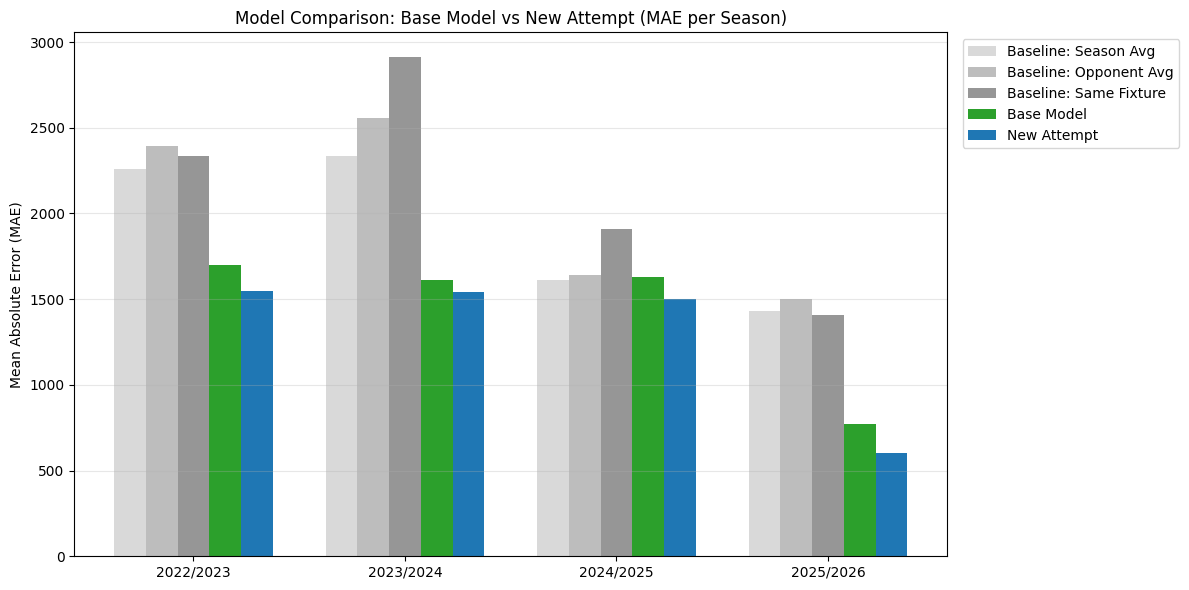

In [36]:
compare_feature_sets(
    df=df, 
    features_1=features_basic, 
    features_2=features_custom, 
    name_1="Base Model", 
    name_2="New Attempt"
)